<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/02_autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Autograd — Notes

**Ali Hamza**
🔗 [linkedin.com/in/alihamzastudent](https://www.linkedin.com/in/alihamzastudent/)

---
Notes on **Autograd** — PyTorch's automatic differentiation engine. This covers the theory behind backpropagation, manual vs. automatic gradient computation, gradient management, and extra autograd features used in real training loops.


## 1. What is Autograd?

Training a neural network means repeatedly asking: *"If I change this weight a little, how much does the loss change?"* That question is answered by a **derivative (gradient)**. For a network with millions of parameters, computing these derivatives by hand is impossible — this is exactly the problem **Autograd** solves.

**Autograd** is PyTorch's automatic differentiation engine. Whenever you perform an operation on a tensor with `requires_grad=True`, PyTorch secretly builds a **computational graph** behind the scenes, recording every operation. When you call `.backward()`, PyTorch walks this graph backward and applies the **chain rule** automatically to compute the gradient of the output with respect to every tensor that fed into it.

This is the mechanism that makes **backpropagation** in deep learning possible — without autograd, every gradient in every layer of a network would need to be derived and coded by hand.

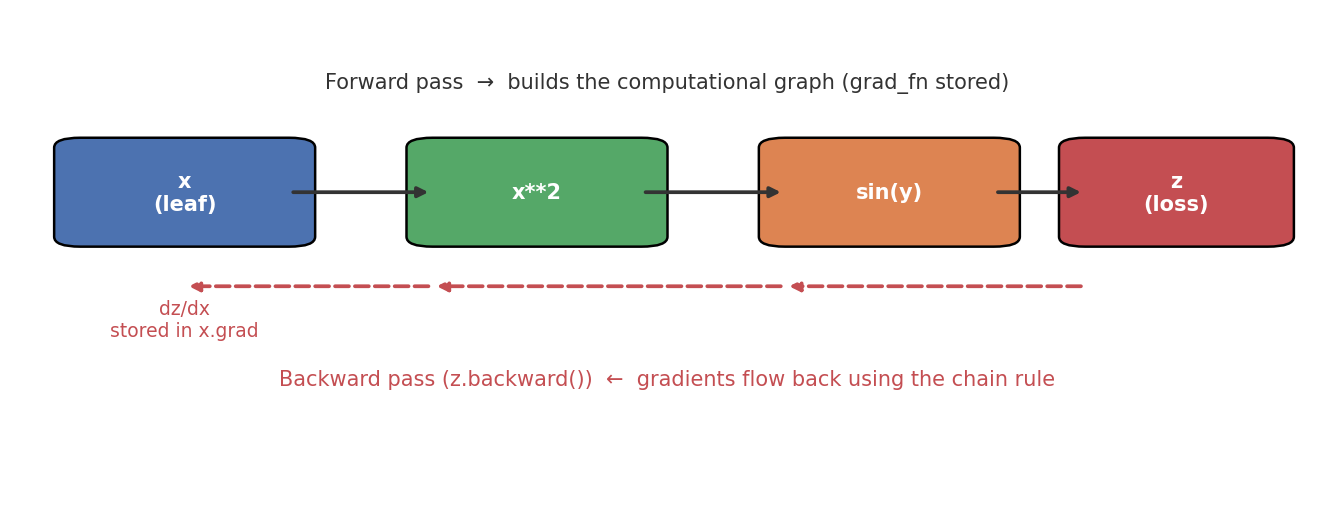


## 2. A Simple Derivative — Manual vs Autograd

Before using PyTorch, let's manually compute a derivative in plain Python to build intuition. For `y = x²`, the derivative `dy/dx = 2x`.

In [1]:
def dy_dx(x):
  return 2*x

In [2]:
dy_dx(3)

6

Now let's get PyTorch to compute the **same** derivative automatically, without us writing the formula ourselves.

Key idea: setting **`requires_grad=True`** tells PyTorch "track every operation on this tensor, because I'll need its gradient later."

In [3]:
import torch

In [4]:
x = torch.tensor(3.0, requires_grad=True)

In [5]:
y = x**2

In [6]:
x

tensor(3., requires_grad=True)

In [7]:
y

tensor(9., grad_fn=<PowBackward0>)

Notice `y` shows `grad_fn=<PowBackward0>` — this is PyTorch remembering *how* `y` was produced (by raising `x` to a power), so it knows how to differentiate it later.

**`.backward()`** triggers the actual gradient computation, and the result is stored inside **`.grad`** of the leaf tensor (`x`).

In [8]:
y.backward()

In [9]:
x.grad

tensor(6.)

## 3. Chain Rule Example

Real neural networks are chains of many operations stacked together (linear layer → activation → loss). Autograd handles this automatically using the **chain rule**: for `z = sin(x²)`, manually:

`dz/dx = d(sin(y))/dy * dy/dx = cos(x²) * 2x`


In [10]:
import math
def dz_dx(x):
    return 2 * x * math.cos(x**2)

In [11]:
dz_dx(4)

-7.661275842587077

Now the same thing with autograd — PyTorch chains the gradient through **both** operations (`x**2` then `sin`) automatically:

In [12]:
x = torch.tensor(4.0, requires_grad=True)

In [13]:
y = x ** 2

In [14]:
z = torch.sin(y)

In [15]:
x

tensor(4., requires_grad=True)

In [16]:
y
# y = x**2, an intermediate (non-leaf) result

tensor(16., grad_fn=<PowBackward0>)

In [17]:
z.backward()

In [18]:
x.grad

tensor(-7.6613)

### Leaf vs Non-leaf Tensors

- **Leaf tensor**: created directly by you (e.g. `x = torch.tensor(4.0, requires_grad=True)`). Its `.grad` gets populated after `.backward()`.
- **Non-leaf tensor**: the *result* of an operation (e.g. `y = x**2`). PyTorch does **not** store gradients for non-leaf tensors by default (to save memory) — accessing `y.grad` gives a `UserWarning` and returns `None`.

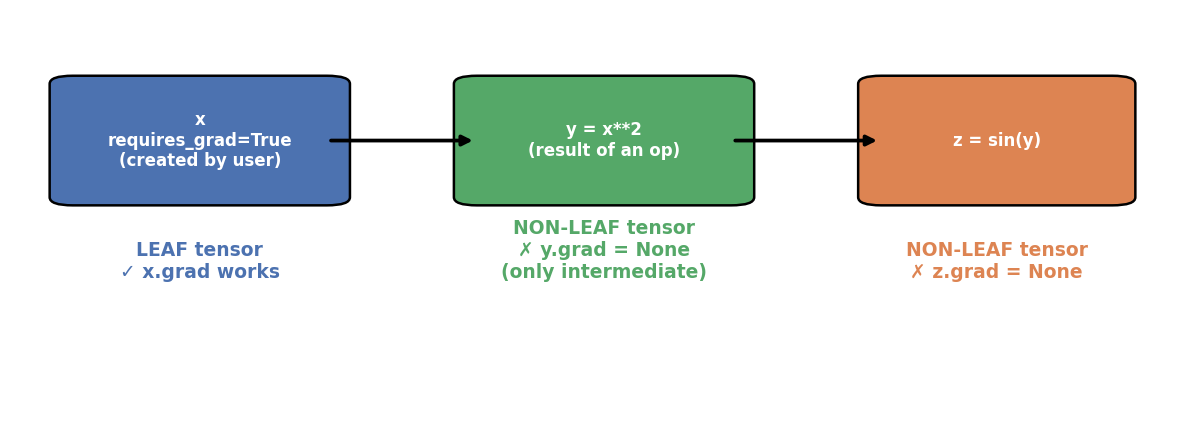


In [19]:
y.grad
# UserWarning: the .grad attribute of a non-leaf Tensor is being accessed.
# Its .grad attribute won't be populated during autograd.backward()

/tmp/ipykernel_1793/1147410300.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  y.grad


## 4. Manual Backpropagation — Logistic Regression

To really understand *why* autograd is valuable, let's compute gradients **by hand** for a tiny logistic regression model (one input, one weight, one bias), and later compare to autograd's answer.

**The model:**
- `z = w*x + b` (linear part)
- `y_pred = sigmoid(z)` (squashes z into a 0–1 probability)
- `loss = Binary Cross-Entropy(y_pred, y)` (measures how wrong the prediction is)


In [20]:
import torch

# Inputs
x = torch.tensor(6.7)  # Input feature
y = torch.tensor(0.0)  # True label (binary)

w = torch.tensor(1.0)  # Weight
b = torch.tensor(0.0)  # Bias

In [21]:
# Binary Cross-Entropy Loss for scalar
def binary_cross_entropy_loss(prediction, target):
    epsilon = 1e-8  # To prevent log(0)
    prediction = torch.clamp(prediction, epsilon, 1 - epsilon)
    return -(target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction))

In [22]:
# Forward pass
z = w * x + b  # Weighted sum (linear part)
y_pred = torch.sigmoid(z)  # Predicted probability

# Compute binary cross-entropy loss
loss = binary_cross_entropy_loss(y_pred, y)

In [23]:
loss

tensor(6.7012)

To train this model we need `dL/dw` and `dL/db` — how much the loss changes if we nudge the weight or bias. By the chain rule, this breaks into three smaller derivatives multiplied together:

`dL/dw = (dL/dy_pred) × (dy_pred/dz) × (dz/dw)`

In [24]:
# Derivatives:
# 1. dL/d(y_pred): Loss with respect to the prediction (y_pred)
dloss_dy_pred = (y_pred - y)/(y_pred*(1-y_pred))

# 2. dy_pred/dz: Prediction (y_pred) with respect to z (sigmoid derivative)
dy_pred_dz = y_pred * (1 - y_pred)

# 3. dz/dw and dz/db: z with respect to w and b
dz_dw = x  # dz/dw = x
dz_db = 1  # dz/db = 1 (bias contributes directly to z)

dL_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db = dloss_dy_pred * dy_pred_dz * dz_db

In [25]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dL_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


## 5. The Same Model — Now With Autograd

This is the whole point of autograd: instead of manually deriving and coding three chained derivatives, we just set `requires_grad=True` and call `.backward()`. PyTorch produces the **exact same gradients**.

In [26]:
x = torch.tensor(6.7)
y = torch.tensor(0.0)

In [27]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [28]:
w

tensor(1., requires_grad=True)

In [29]:
b

tensor(0., requires_grad=True)

In [30]:
z = w*x + b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [31]:
y_pred = torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [32]:
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [33]:
loss.backward()

In [34]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


Compare `w.grad` / `b.grad` above with the manually computed `dL_dw` / `dL_db` earlier — they match. This is why autograd is trusted for training networks with millions of parameters where manual derivation is impossible.

## 6. Autograd with Vector Inputs

So far `x` was a single number. In practice, model parameters are usually **vectors or matrices**. Autograd works the same way — but since `.backward()` needs a **scalar** output, we typically reduce the vector result first (e.g. with `.mean()` or `.sum()`).

In [35]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

In [36]:
x

tensor([1., 2., 3.], requires_grad=True)

In [37]:
y = (x**2).mean()
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [38]:
y.backward()

In [39]:
x.grad
# gradient computed element-wise: d(mean(x^2))/dx = 2x/n for each element

tensor([0.6667, 1.3333, 2.0000])

## 7. Clearing Gradients

**Important:** PyTorch **accumulates** gradients by default — every time you call `.backward()`, the new gradient is *added* to whatever is already in `.grad`, not replaced. This is why every training loop calls `optimizer.zero_grad()` (or `tensor.grad.zero_()`) before each backward pass — otherwise gradients from previous steps would incorrectly pile up.

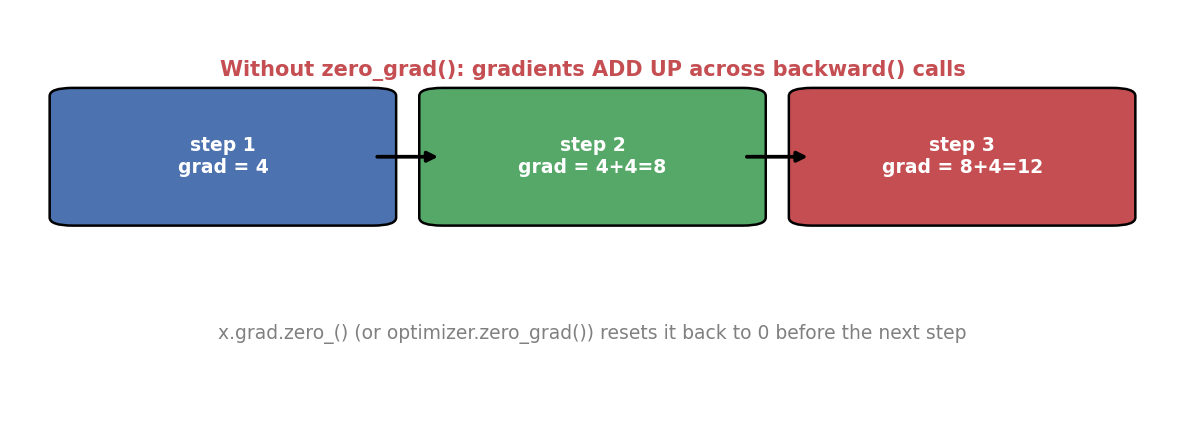


In [40]:
# clearing grad
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [41]:
y = x ** 2
y

tensor(4., grad_fn=<PowBackward0>)

In [42]:
y.backward()

In [43]:
x.grad

tensor(4.)

In [44]:
x.grad.zero_()
# resets the accumulated gradient back to 0

tensor(0.)

## 8. Disabling Gradient Tracking

Once a model is trained, we don't need autograd anymore when just running predictions (inference) — tracking gradients wastes memory and compute. PyTorch gives **three ways** to stop tracking gradients:

1. **`requires_grad_(False)`** — permanently turns off tracking on that tensor (in-place).
2. **`.detach()`** — creates a new tensor that shares the same data but is *disconnected* from the computational graph.
3. **`torch.no_grad()`** — a context manager that disables tracking for everything inside its block (most commonly used during evaluation/inference).


In [45]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [46]:
y = x ** 2
y

tensor(4., grad_fn=<PowBackward0>)

In [47]:
y.backward()

In [48]:
x.grad

tensor(4.)

### Option 1 — `requires_grad_(False)`

In [49]:
x.requires_grad_(False)
x

tensor(2.)

In [50]:
y = x ** 2
y
# notice: no grad_fn anymore, since x is no longer tracked

tensor(4.)

In [51]:
# y.backward()
# RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

### Option 2 — `.detach()`

In [52]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [53]:
z = x.detach()
z
# z has the same value as x, but is disconnected from the graph (no grad_fn)

tensor(2.)

In [54]:
y = x ** 2
y
# y is still tracked, since it came from the original x

tensor(4., grad_fn=<PowBackward0>)

In [55]:
y1 = z ** 2
y1
# y1 has no grad_fn, since z was detached

tensor(4.)

In [56]:
y.backward()
# works fine, since y is connected to x

In [57]:
# y1.backward()
# RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

### Option 3 — `torch.no_grad()`

In [58]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [59]:
with torch.no_grad():
    y = x ** 2

y
# no grad_fn at all, since everything inside the block skips tracking

tensor(4.)

In [60]:
# y.backward()
# RuntimeError: this y has no grad_fn since it was created inside torch.no_grad()

## 9.  Feature — `torch.autograd.grad()`

Besides `.backward()` (which stores results inside `.grad`), PyTorch offers a **functional API**: `torch.autograd.grad(outputs, inputs)`. It directly **returns** the gradient instead of storing it — useful when you don't want to touch `.grad` at all, or need the gradient as a standalone value (common in meta-learning and some custom training loops).

In [61]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

grad = torch.autograd.grad(outputs=y, inputs=x)
print(grad)   # returned directly as a tuple, x.grad is NOT touched

(tensor(6.),)


## 10.  Feature — `retain_graph`

By default, PyTorch **frees the computational graph** right after `.backward()` runs, to save memory — calling `.backward()` a second time on the same graph raises an error. Passing **`retain_graph=True`** keeps the graph alive so you can call `.backward()` more than once (e.g. needed for computing multiple different losses from the same forward pass).

In [62]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3

y.backward(retain_graph=True)
print(x.grad)

x.grad.zero_()
y.backward()   # works again, since the graph was retained
print(x.grad)

tensor(12.)
tensor(12.)


## 11.  Feature — Backward on Non-Scalar Outputs

`.backward()` normally requires a **scalar** output (a single number), because "the gradient of a vector with respect to another vector" isn't a single number — it's a full Jacobian matrix. If the output is a vector, PyTorch needs a `gradient` argument telling it how to weight each output element (conceptually: **vector-Jacobian product**).

In [63]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2   # y is a vector: [1, 4, 9], NOT a scalar

# y.backward()  # would error: grad can be implicitly created only for scalar outputs

# instead, provide a weight for each output element
weights = torch.tensor([1.0, 1.0, 1.0])
y.backward(gradient=weights)
print(x.grad)

tensor([2., 4., 6.])


## 12. Why This Matters — The Training Loop

Every PyTorch training loop follows the same autograd-powered pattern:

```python
for epoch in range(epochs):
    y_pred = model(x)              # forward pass (builds graph)
    loss = loss_fn(y_pred, y)      # compute loss
    optimizer.zero_grad()          # clear old gradients (see Section 7)
    loss.backward()                # compute new gradients (autograd)
    optimizer.step()               # update weights using the gradients
```

Everything covered in this notebook — the computational graph, leaf tensors, chain rule, gradient accumulation, and `no_grad()` — comes together in exactly these five lines, which are the heart of training every neural network in PyTorch.

---
### Summary

- **Autograd** automatically builds a computational graph and applies the chain rule to compute gradients via `.backward()`.
- **Leaf tensors** (created by you) store gradients in `.grad`; **non-leaf tensors** (results of operations) don't, by default.
- Manually deriving gradients (as done for logistic regression here) shows *why* autograd is essential — it gives identical results without hand-derived formulas.
- Gradients **accumulate** across `.backward()` calls — always clear with `zero_grad()` / `.grad.zero_()` between steps.
- Disable tracking during inference using **`requires_grad_(False)`**, **`.detach()`**, or **`torch.no_grad()`**.
- `torch.autograd.grad()` gives gradients directly without touching `.grad`; `retain_graph=True` allows multiple backward passes; a `gradient` argument is needed for non-scalar `.backward()` calls.
- All of this powers the standard training loop: forward → zero_grad → backward → step.

Next step: **Building and training a neural network with `torch.nn` (Linear layers, activation functions, loss functions, optimizers).**
